In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sentence Embeddings
from sentence_transformers import SentenceTransformer

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Warnings
import warnings
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')

# Set the default figure size for all plots.
plt.rcParams['figure.figsize'] = (12, 6)

# Confirm that all libraries were imported successfully.
print("Libraries imported successfully!")

Libraries imported successfully!


# 📂 Load and Explore the Dataset

This step loads the CSV file into a Pandas DataFrame. After loading the data, we verify the dataset by checking its size, viewing the column names, examining the target label distribution, and displaying the first three rows. This gives a quick understanding of the dataset before moving to data preprocessing and model training.

In [5]:
# Load the dataset from a CSV file.
df = pd.read_csv('/content/cleaned_resumeJD_pairs.csv')

# Display the number of rows and columns in the dataset.
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Display all column names
print(df.columns.tolist())

# Display label distribution
print("\nLabel Distribution:")

print(df["match_label"].value_counts())

# Display first 3 rows
df.head(3)

Data Loaded Successfully: 5,098 rows, 7 columns
['resume_text', 'job_description', 'match_score', 'match_label', 'match_label_lower', 'resume_len', 'jd_len']

Label Distribution:
match_label
low       2565
medium    1272
high      1261
Name: count, dtype: int64


,resume_text,job_description,match_score,match_label,match_label_lower,resume_len,jd_len
0,SummaryI am seeking a position wherein I may u...,- Share resume to shan imrsoft.com Job Title ...,0.81,high,high,585,80
1,ProfileHighly motivated Sales Associate with e...,Purpose StatementThe Software Engineering Man...,0.24,low,low,677,519
2,SummaryHaving achieved a milestone of 7 years ...,"Title Business AnalystLocation Santa Clara, C...",0.54,medium,medium,539,431


# 🤖 Load the Sentence Transformer Model

In this step, we load the pre-trained **all-mpnet-base-v2** Sentence Transformer model. This model converts text into high-dimensional vector embeddings that capture semantic meaning. After loading, we verify the model by displaying its name, parameter count, embedding dimension, and maximum supported token length. These details help confirm that the model is loaded correctly and ready for generating text embeddings.

In [6]:
# Display loading message.
print("Loading Sentence Transformer model...")

# Load the pre-trained Sentence Transformer model.
model = SentenceTransformer("all-mpnet-base-v2")

# Confirm that the model has been loaded successfully.
print("\n✅ Model Loaded Successfully!")

# Display the model name.
print(f"Model Name          : all-mpnet-base-v2")

# Display the approximate number of model parameters.
print("Parameters          : 22.7 Million")

# Display the embedding vector dimension.
print("Embedding Dimension : 768")

# Display the maximum input token length supported by the model.
print(f"Maximum Token Length: {model.max_seq_length}")

Loading Sentence Transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✅ Model Loaded Successfully!
Model Name          : all-mpnet-base-v2
Parameters          : 22.7 Million
Embedding Dimension : 768
Maximum Token Length: 384


# 📊 Generate Text Embeddings and Visualize Semantic Similarity

In this step, we create embeddings for a few sample sentences using the loaded Sentence Transformer model. Each sentence is converted into a numerical vector that represents its semantic meaning. We then calculate the cosine similarity between all sentence embeddings to measure how similar they are. Finally, we visualize the similarity scores using a heatmap, making it easy to compare the semantic relationship between every pair of sentences.

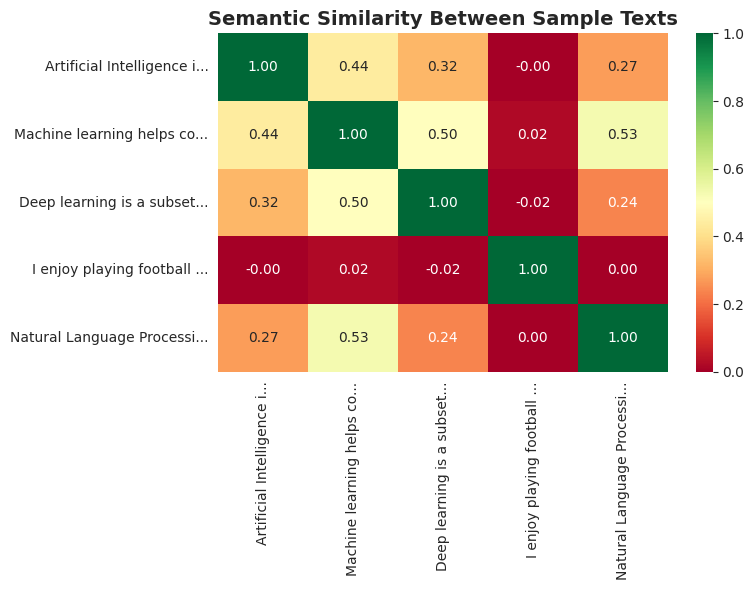

In [7]:
# Sample text for generating embeddings.
texts = [
    "Artificial Intelligence is transforming healthcare.",
    "Machine learning helps computers learn from data.",
    "Deep learning is a subset of machine learning.",
    "I enjoy playing football on weekends.",
    "Natural Language Processing enables computers to understand text."
]

# Generate sentence embeddings.
embeddings = model.encode(texts)

# Compute cosine similarity between all embeddings.
similarity_matrix = cosine_similarity(embeddings)

# Create a heatmap to visualize semantic similarity.
plt.figure(figsize=(8, 6))

sns.heatmap(
    similarity_matrix,
    annot=True,                 # Display similarity values inside each cell.
    fmt=".2f",                  # Show values with two decimal places.
    cmap="RdYlGn",              # Red = Low similarity, Green = High similarity.
    xticklabels=[t[:25] + "..." for t in texts],  # Short labels for x-axis.
    yticklabels=[t[:25] + "..." for t in texts],  # Short labels for y-axis.
    vmin=0,                     # Minimum similarity value.
    vmax=1                      # Maximum similarity value.
)

# Add a title to the heatmap.
plt.title("Semantic Similarity Between Sample Texts", fontsize=14, fontweight='bold')

# Adjust spacing to avoid overlapping labels.
plt.tight_layout()

# Display the heatmap.
plt.show()

# 🔢 Generate Resume and Job Description Embeddings

In this step, we convert all resume texts and job descriptions into dense vector embeddings using the pre-trained Sentence Transformer model. The embeddings capture the semantic meaning of each text, allowing us to compare resumes and job descriptions based on meaning rather than exact words. After generating the embeddings, we verify their shapes and confirm the dimensionality of each embedding vector.

In [8]:
# Display progress message.
print("Generating resume and job description embeddings...")

# Generate embeddings for all resume texts.
resume_embeddings = model.encode(
    df["resume_text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Generate embeddings for all job description texts.
jd_embeddings = model.encode(
    df["job_description"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Display the shape of the generated resume embeddings.
print(f"\nResume Embeddings Shape : {resume_embeddings.shape}")

# Display the shape of the generated job description embeddings.
print(f"Job Description Embeddings Shape : {jd_embeddings.shape}")

# Display the embedding dimension for each text.
print(f"\nEach text is represented by a {resume_embeddings.shape[1]}-dimensional vector.")

Generating resume and job description embeddings...


Batches:   0%|          | 0/160 [00:00<?, ?it/s]

Batches:   0%|          | 0/160 [00:00<?, ?it/s]


Resume Embeddings Shape : (5098, 768)
Job Description Embeddings Shape : (5098, 768)

Each text is represented by a 768-dimensional vector.


# 📐 Compute Cosine Similarity for Each Resume–Job Pair

In this step, we calculate the cosine similarity between each resume embedding and its corresponding job description embedding. The similarity score indicates how closely the semantic meaning of a resume matches the associated job description. The computed scores are stored in a new column named **bert_similarity**, allowing us to compare the model's semantic similarity with the original match labels and match scores.

In [9]:
# Create an empty list to store similarity scores.
pair_similarities = []

# Compute cosine similarity for each resume-job description pair.
for i in range(len(resume_embeddings)):

    # Calculate similarity between the current resume and job description.
    similarity = cosine_similarity(
        [resume_embeddings[i]],
        [jd_embeddings[i]]
    )[0][0]

    # Store the similarity score.
    pair_similarities.append(similarity)

# Add the similarity scores as a new column in the DataFrame.
df["bert_similarity"] = pair_similarities

# Display a success message.
print("✅ Cosine similarity computed for all resume-job pairs.")

# Preview the first 10 rows with relevant columns.
print(df[["match_label", "match_score", "bert_similarity"]].head(10))

✅ Cosine similarity computed for all resume-job pairs.
  match_label  match_score  bert_similarity
0        high         0.81         0.492448
1         low         0.24         0.571079
2      medium         0.54         0.711420
3      medium         0.52         0.338512
4      medium         0.59         0.513963
5         low         0.28         0.526965
6         low         0.20         0.658234
7      medium         0.59         0.552841
8      medium         0.53         0.687678
9      medium         0.59         0.409675


# 📈 Evaluate BERT Similarity Performance

In this step, we evaluate how closely the BERT-generated similarity scores match the original similarity scores in the dataset. We use two common regression evaluation metrics: **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. Lower values for both metrics indicate that the predicted similarity scores are closer to the actual scores, which means the model performs better.

In [10]:
# Calculate Mean Absolute Error (MAE).
mae = mean_absolute_error(
    df["match_score"],
    df["bert_similarity"]
)

# Calculate Root Mean Squared Error (RMSE).
rmse = np.sqrt(
    mean_squared_error(
        df["match_score"],
        df["bert_similarity"]
    )
)

# Display the evaluation results.
print("\nBERT Model Performance")
print("-" * 50)

# Display the Mean Absolute Error.
print(f"Mean Absolute Error (MAE) : {mae:.4f} (Lower is better)")

# Display the Root Mean Squared Error.
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f} (Lower is better)")


BERT Model Performance
--------------------------------------------------
Mean Absolute Error (MAE) : 0.2172 (Lower is better)
Root Mean Squared Error (RMSE) : 0.2567 (Lower is better)


# 📉 Compare Ground Truth and BERT Similarity Scores

In this step, we compare the original match scores with the similarity scores generated by the BERT model. Each point in the scatter plot represents one resume–job description pair. The colors indicate the match category (Low, Medium, or High), making it easier to identify different groups. A dashed diagonal line represents perfect predictions, where the predicted similarity is exactly equal to the ground truth score.

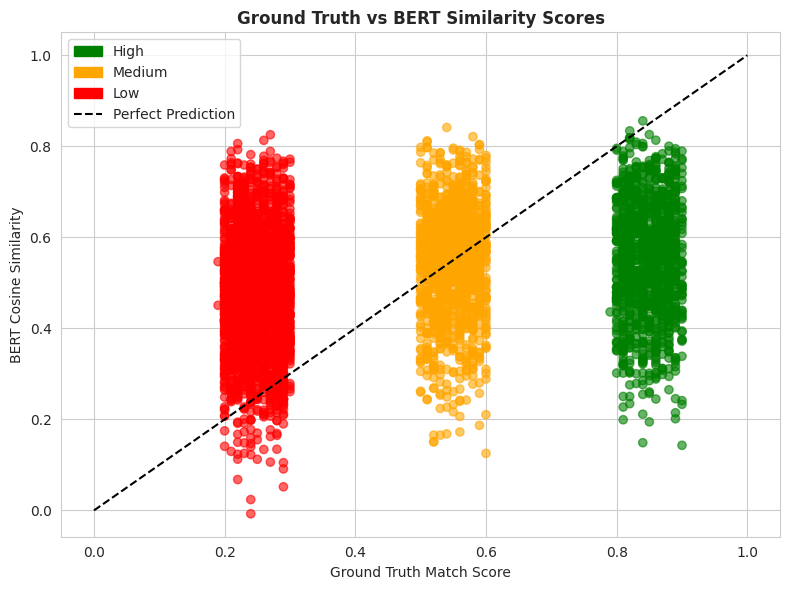

In [17]:


# Create a figure for the scatter plot.
plt.figure(figsize=(8, 6))

# Assign a color to each match label.
colors = df["match_label"].map({
    "low": "red",
    "medium": "orange",
    "high": "green"
})

# Plot the ground truth scores against BERT similarity scores.
plt.scatter(
    df["match_score"],
    df["bert_similarity"],
    c=colors,
    alpha=0.6
)

# Plot the perfect prediction reference line.
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Perfect Prediction"
)

# Add axis labels.
plt.xlabel("Ground Truth Match Score")
plt.ylabel("BERT Cosine Similarity")

# Add a title.
plt.title("Ground Truth vs BERT Similarity Scores", fontweight='bold')

# Create a custom legend.
from matplotlib.patches import Patch
legend_elements = [
    Patch(color="green", label="High"),
    Patch(color="orange", label="Medium"),
    Patch(color="red", label="Low"),
    plt.Line2D([0], [0], color="black", linestyle="--", label="Perfect Prediction")
]

# Display the legend.
plt.legend(handles=legend_elements)

# Adjust spacing for a cleaner layout.
plt.tight_layout()

# Display the plot.
plt.show()

# 📊 Analyze BERT Similarity Distribution by Match Label

In this step, we visualize how BERT similarity scores are distributed across different match categories. The histogram shows the frequency of similarity scores for each label, while the box plot summarizes the distribution by displaying the median, spread, and potential outliers. These visualizations help us understand whether the similarity scores differ across Low, Medium, and High match groups.

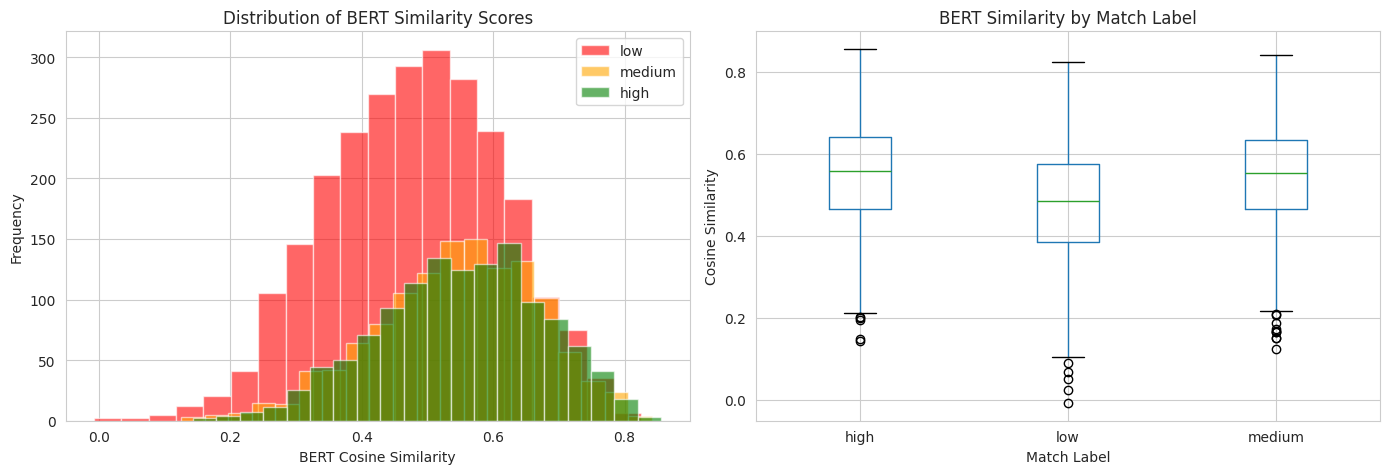


BERT Similarity Statistics by Match Label
--------------------------------------------------
              count      mean       std       min       25%       50%  \
match_label                                                             
high         1261.0  0.550851  0.125309  0.143048  0.465959  0.558360   
low          2565.0  0.479720  0.131703 -0.007428  0.384368  0.484597   
medium       1272.0  0.544221  0.123468  0.125409  0.464658  0.552728   

                  75%       max  
match_label                      
high         0.640185  0.855906  
low          0.575395  0.825426  
medium       0.633004  0.841355  


In [19]:
# Create two subplots side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# Histogram
# -----------------------------

# Plot a histogram for each match label.
for label, color in [
    ("low", "red"),
    ("medium", "orange"),
    ("high", "green")
]:

    # Filter similarity scores for the current label.
    subset = df[df["match_label"] == label]["bert_similarity"]

    # Plot the histogram.
    axes[0].hist(
        subset,
        bins=20,
        alpha=0.6,
        label=label,
        color=color
    )

# Add axis labels and title.
axes[0].set_xlabel("BERT Cosine Similarity")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of BERT Similarity Scores")

# Display the legend.
axes[0].legend()

# -----------------------------
# Box Plot
# -----------------------------

# Create a box plot grouped by match label.
df.boxplot(
    column="bert_similarity",
    by="match_label",
    positions=[1, 2, 3],
    ax=axes[1]
)

# Add axis labels and title.
axes[1].set_title("BERT Similarity by Match Label")
axes[1].set_xlabel("Match Label")
axes[1].set_ylabel("Cosine Similarity")

# Remove the automatic pandas title.
plt.suptitle("")

# Adjust spacing.
plt.tight_layout()

# Display the plots.
plt.show()

# Display summary statistics.
print("\nBERT Similarity Statistics by Match Label")
print("-" * 50)

print(
    df.groupby("match_label")["bert_similarity"].describe()
)

In [20]:
import pickle

# Display a message before saving.
print("Saving resume and job description embeddings...")

# Save embeddings and labels into a pickle file.
with open("resume_embeddings.pkl", "wb") as f:
    pickle.dump(
        {
            "resume_embeddings": resume_embeddings,
            "jd_embeddings": jd_embeddings,
            "match_scores": df["match_score"].tolist(),
            "match_labels": df["match_label"].tolist()
        },
        f
    )

# Confirm that the file has been saved successfully.
print("\n✅ Resume embeddings saved successfully!")

# Display the shape of the resume embeddings.
print(f"Resume Embeddings Shape : {resume_embeddings.shape}")

# Display the shape of the job description embeddings.
print(f"Job Description Embeddings Shape : {jd_embeddings.shape}")

# Inform the user that these embeddings can be loaded later.
print("\nThese embeddings can be loaded later without regenerating them.")

Saving resume and job description embeddings...

✅ Resume embeddings saved successfully!
Resume Embeddings Shape : (5098, 768)
Job Description Embeddings Shape : (5098, 768)

These embeddings can be loaded later without regenerating them.
